# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

In [1]:
# Part 0: your work here
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd

NETID = 'anuvacg2'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True)
x, ex, y, ey = d['logMstar'], d['err_logMstar'], d['logMBH'], d['err_logMBH']

data = pd.DataFrame({'logstar': x, 'elogstar': ex, 'logmbh': y, 'elogmbh': ey})
print(data)

      logstar  elogstar    logmbh   elogmbh
0    7.469538  0.242763  5.126162  0.391768
1    8.216688  0.294281  5.615980  0.289276
2    8.262845  0.273457  5.401394  0.252676
3    8.569980  0.294939  5.501934  0.272073
4    8.706252  0.251703  5.630770  0.374677
5    8.711808  0.215850  5.687143  0.375072
6    8.791891  0.240987  5.672890  0.335185
7    9.016809  0.238976  4.923746  0.390976
8    9.028385  0.313000  7.187876  0.383845
9    9.142923  0.242705  4.604566  0.333526
10   9.151790  0.243912  5.630688  0.312467
11   9.167977  0.370019  6.649889  0.341233
12   9.320182  0.377910  5.288325  0.328734
13   9.327634  0.231945  5.721183  0.285081
14   9.372918  0.202771  5.398644  0.362548
15   9.492605  0.388709  5.531928  0.325169
16   9.639663  0.253421  6.890412  0.266604
17   9.678618  0.289566  6.760415  0.393667
18   9.761437  0.299852  5.947875  0.350862
19   9.782857  0.206820  6.142711  0.331637
20   9.880511  0.226178  6.588753  0.274299
21  10.136533  0.310834  6.51387

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

OLS alpha = 0.640 +/- 0.152
OLS beta  = 6.121 +/- 0.117
residual rms = 0.598 dex
Var(x_obs) = 0.595, <sigma_x^2> = 0.082, expected slope attenuation factor ~ 0.862


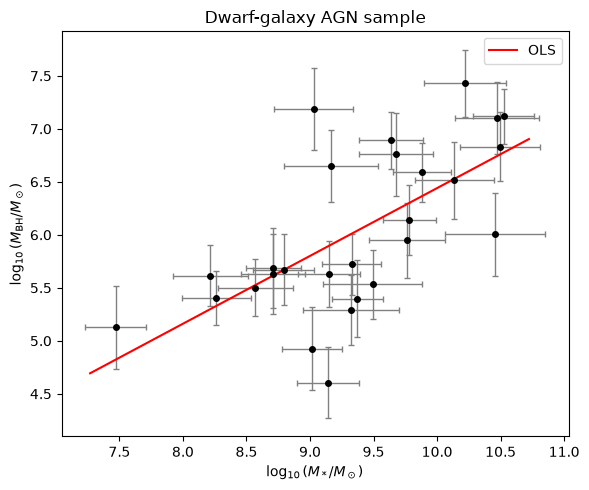

In [2]:
# Part 1: your work here 
import numpy as np
import matplotlib.pyplot as plt

N = len(x)
fig, ax = plt.subplots(figsize=(6, 5))
ax.errorbar(x, y, xerr=ex, yerr=ey, fmt='o', ms=4, color='k',
            ecolor='gray', elinewidth=1, capsize=2)
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
ax.set_ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
ax.set_title('Dwarf-galaxy AGN sample')

A = np.column_stack([x - 9.5, np.ones(N)])
theta = np.linalg.solve(A.T @ A, A.T @ y)
resid = y - A @ theta
s2 = resid @ resid / (N - 2)
cov = s2 * np.linalg.inv(A.T @ A)
alpha_ols, beta_ols = theta
sig_alpha, sig_beta = np.sqrt(np.diag(cov))

print(f"OLS alpha = {alpha_ols:.3f} +/- {sig_alpha:.3f}")
print(f"OLS beta  = {beta_ols:.3f} +/- {sig_beta:.3f}")
print(f"residual rms = {np.sqrt(s2):.3f} dex")

lam = 1 - np.mean(ex**2) / np.var(x, ddof=1)
print(f"Var(x_obs) = {np.var(x, ddof=1):.3f}, <sigma_x^2> = {np.mean(ex**2):.3f}, "
      f"expected slope attenuation factor ~ {lam:.3f}")

xx = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
ax.plot(xx, alpha_ols * (xx - 9.5) + beta_ols, 'r-', label='OLS')
ax.legend()
plt.tight_layout()
plt.show()

**ANSWER (a few sentences):**
OLS assumes that error only happens on the y-dimesion, implying that your x-values are trustworthy and exact. neither of these assumptions are true, and the data has intrinsic scatter that OLS cannot accurately account for. 
The bias scales towards the fraction of the observed x-data that is measurement noise, so it has larger errors when the x range is narrow. The quoted variation in alpha does not correctly account for this bias. 

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

C:\Users\Anuva\AppData\Local\Temp\ipykernel_28204\961315077.py:5: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy import odr


WLS: alpha = 0.682 +/- 0.082, beta = 6.150 +/- 0.063
ODR: alpha = 0.915 +/- 0.160, beta = 6.170 +/- 0.116
Hessian eigenvalues (all > 0 => not singular): [32.08023097 46.72912808 82.36215603 91.44771028 97.43991896]
ML:  alpha     = 0.783 +/- 0.167
ML:  beta      = 6.153 +/- 0.109
ML:  sigma_int = 0.382 +/- 0.114
ML:  mu        = 9.354 +/- 0.145
ML:  sigma_pop = 0.698 +/- 0.110
3x rule cap on sigma_alpha: 0.5022841471288837


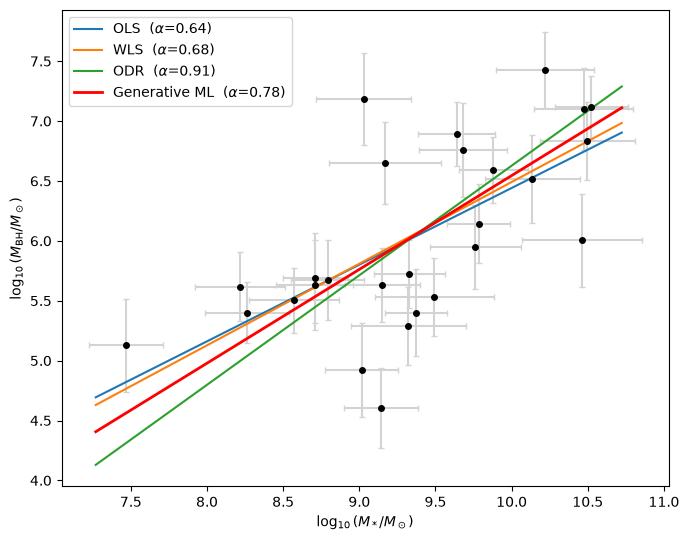

In [3]:
# Part 2: your work here

import warnings
from scipy.optimize import minimize
from scipy import odr

# Weighted least squares (y-errors only)
W = 1 / ey**2
cov_wls = np.linalg.inv(A.T @ (A * W[:, None]))
th_wls = cov_wls @ (A.T @ (W * y))
sig_wls = np.sqrt(np.diag(cov_wls))
print(f"WLS: alpha = {th_wls[0]:.3f} +/- {sig_wls[0]:.3f}, beta = {th_wls[1]:.3f} +/- {sig_wls[1]:.3f}")

# Orthogonal distance regression 
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    def line(B, xx): return B[0] * (xx - 9.5) + B[1]
    out = odr.ODR(odr.RealData(x, y, sx=ex, sy=ey), odr.Model(line), beta0=[1., 6.]).run()
th_odr, sig_odr = out.beta, out.sd_beta
print(f"ODR: alpha = {th_odr[0]:.3f} +/- {sig_odr[0]:.3f}, beta = {th_odr[1]:.3f} +/- {sig_odr[1]:.3f}")

#  Generative (bivariate Gaussian) maximum likelihood 
def nll(p):
    a, b, lsi, mu, lsp = p
    si2, sp2 = np.exp(2 * lsi), np.exp(2 * lsp)
    vxx = sp2 + ex**2
    vxy = a * sp2
    vyy = a**2 * sp2 + si2 + ey**2
    dx = x - mu
    dy = y - (a * (mu - 9.5) + b)
    det = vxx * vyy - vxy**2
    q = (vyy * dx**2 - 2 * vxy * dx * dy + vxx * dy**2) / det
    return 0.5 * np.sum(q + np.log(det)) + N * np.log(2 * np.pi)

best = None
for a0 in [0.3, 0.8, 1.5]:
    for si0 in [0.1, 0.4, 0.8]:
        p0 = [a0, 6.0, np.log(si0), x.mean(), np.log(x.std())]
        r = minimize(nll, p0, method='Nelder-Mead',
                     options=dict(xatol=1e-9, fatol=1e-12, maxiter=20000, maxfev=20000))
        r = minimize(nll, r.x, method='BFGS')
        if best is None or r.fun < best.fun:
            best = r
a_ml, b_ml = best.x[0], best.x[1]
si_ml, mu_ml, sp_ml = np.exp(best.x[2]), best.x[3], np.exp(best.x[4])

def nll_native(q):
    return nll([q[0], q[1], np.log(abs(q[2])), q[3], np.log(abs(q[4]))])

def num_hessian(fn, q, h=1e-3):
    n = len(q); H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei, ej = np.eye(n)[i] * h, np.eye(n)[j] * h
            H[i, j] = (fn(q+ei+ej) - fn(q+ei-ej) - fn(q-ei+ej) + fn(q-ei-ej)) / (4*h*h)
    return H

q_ml = np.array([a_ml, b_ml, si_ml, mu_ml, sp_ml])
H = num_hessian(nll_native, q_ml)
print("Hessian eigenvalues (all > 0 => not singular):", np.linalg.eigvalsh(H))
sig_ml = np.sqrt(np.diag(np.linalg.inv(H)))
names = ['alpha', 'beta', 'sigma_int', 'mu', 'sigma_pop']
for n_, v, s in zip(names, q_ml, sig_ml):
    print(f"ML:  {n_:9s} = {v:.3f} +/- {s:.3f}")
print("3x rule cap on sigma_alpha:", 3 * sig_ml[0])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.errorbar(x, y, xerr=ex, yerr=ey, fmt='o', ms=4, color='k', ecolor='lightgray', capsize=2)
xx = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
ax.plot(xx, alpha_ols*(xx-9.5) + beta_ols, label=f'OLS  ($\\alpha$={alpha_ols:.2f})')
ax.plot(xx, th_wls[0]*(xx-9.5) + th_wls[1], label=f'WLS  ($\\alpha$={th_wls[0]:.2f})')
ax.plot(xx, th_odr[0]*(xx-9.5) + th_odr[1], label=f'ODR  ($\\alpha$={th_odr[0]:.2f})')
ax.plot(xx, a_ml*(xx-9.5) + b_ml, 'r-', lw=2, label=f'Generative ML  ($\\alpha$={a_ml:.2f})')
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$'); ax.set_ylabel(r'$\log_{10}(M_{\rm BH}/M_\odot)$')
ax.legend(); plt.tight_layout(); plt.show()

This weighting does not fix the part 1 errors, since WLS only uses the y-errors and ignores the x-error. This creates an overconfident error bar because it treats intrinsic scatter as if it were measurement noise.. \
ODR assumes there is 0 intrinsic scatter, so it overcorrects on the residuals and makes the slope much steeper than it needs to be. 

OLS: Standard ordinary least-squares fit, assumes only error in y and exact x-values. \
WLS: Weighted least squares accounts for y-error but still ignores x-error. \
ODR: Accounts for x-scatter but assumes no inherent scatter. \
Gen ML: Can reliably account for intrinsic scatter and errors in both dimensions. 

**FINAL ANSWER:** $\alpha = $ 0.783 $\pm$ 0.167 , $\beta = $ 6.153 $\pm$ 0.109 , $\sigma_{\rm int} = $ 0.382 $\pm$ 0.114 dex

**Justification and uncertainty method (a short paragraph):**

The generative ML model fits best for the conditions this data was gathered under, since it can account for errors in both variables and the inherent scatter of the readings. The other methods all have their own assumptions that do not hold against the data's collection, since they rely on controls against x and y scatter. Visually and mathematically, the Gen ML model has the most defensible fit for this data.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

Closure: Simulate a dataset with N=250 from a given truth and see if any parameter lies between 2 and 3 (or more) standard deviations from the expected values. \
Bias: Run OLS, WLS, ODR, and Gen ML on hundreds of simulated data sets and see if ML compares to OLS.  \
Coverage: See how frequently the alpha, beta, and sigma_int intervals lie within 1 standard deviation. \
Sensitivity: Fit with over and underscaled x-errors and check if the bias lies outside 0.5 deviations. 

closure pulls (alpha, beta, sint): [0.21796288 0.7603751  0.68718226]
OLS: bias=-0.107 std=0.140 cov68=0.54
WLS: bias=-0.105 std=0.142 cov68=0.33
ODR: bias=+0.153 std=0.205 cov68=0.49
ML: bias=+0.023 std=0.173 cov68=0.71
ML alpha coverage: 0.71
ML beta coverage: 0.66
ML sint coverage: 0.69


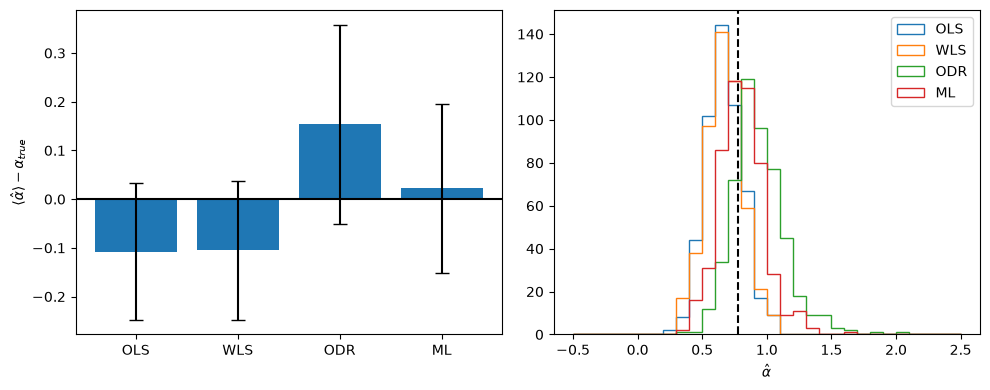

baseline: bias=-0.001 cov68=0.66
ex x0.5: bias=-0.095 cov68=0.51
ex x1.5: bias=+0.198 cov68=0.53
uniform population: bias=+0.024 cov68=0.66
sigma_int=0: bias=+0.142 cov68=0.00


In [6]:
# Part 3b: execute the plan here

def nll(p, x, y, ex, ey, fix=None):
    a, b, lsi, mu, lsp = p
    si2 = np.exp(2*lsi) if fix is None else fix**2
    sp2 = np.exp(2*lsp)
    vxx, vxy, vyy = sp2 + ex**2, a*sp2, a**2*sp2 + si2 + ey**2
    dx, dy = x - mu, y - (a*(mu - 9.5) + b)
    det = vxx*vyy - vxy**2
    return 0.5*np.sum((vyy*dx**2 - 2*vxy*dx*dy + vxx*dy**2)/det + np.log(det))

def fit_ml(x, y, ex, ey, fix=None):
    """Returns (alpha, beta, sint), (sig_alpha, sig_beta, sig_sint); errors from the Hessian."""
    best = min((minimize(nll, [a0, y.mean(), np.log(s0), x.mean(), np.log(x.std())],
                         args=(x, y, ex, ey, fix), method='BFGS')
                for a0 in (0.4, 1.0) for s0 in (0.15, 0.5)), key=lambda r: r.fun)
    a, b, lsi, mu, lsp = best.x
    q = np.array([a, b, np.exp(lsi) if fix is None else fix, mu, np.exp(lsp)])
    if fix is not None: return q[:3], np.full(3, np.nan)
    f = lambda q_: nll([q_[0], q_[1], np.log(abs(q_[2])), q_[3], np.log(abs(q_[4]))], x, y, ex, ey)
    h, H = 1e-3, np.zeros((5, 5))
    for i in range(5):
        for j in range(5):
            ei, ej = np.eye(5)[i]*h, np.eye(5)[j]*h
            H[i, j] = (f(q+ei+ej) - f(q+ei-ej) - f(q-ei+ej) + f(q-ei-ej))/(4*h*h)
    return q[:3], np.sqrt(np.diag(np.linalg.inv(H)))[:3]

def simulate(rng, truth, ex, ey, pop='gauss'):
    a, b, si, mu, sp = truth; n = len(ex)
    xt = rng.normal(mu, sp, n) if pop == 'gauss' else rng.uniform(mu - np.sqrt(3)*sp, mu + np.sqrt(3)*sp, n)
    yt = a*(xt - 9.5) + b + rng.normal(0, si, n)
    return xt + rng.normal(0, 1, n)*ex, yt + rng.normal(0, 1, n)*ey

# some given truth
truth = np.array([0.78, 6.15, 0.38, 9.35, 0.70]); ta = truth[0]
rng = np.random.default_rng(457)

# Estimators from Parts 1-2, wrapped to return (theta, sigma)
def fit_ols(x, y, ex, ey):
    A = np.c_[x - 9.5, np.ones(len(x))]; th = np.linalg.solve(A.T@A, A.T@y); r = y - A@th
    return th, np.sqrt(np.diag(r@r/(len(x)-2)*np.linalg.inv(A.T@A)))
def fit_wls(x, y, ex, ey):
    A = np.c_[x - 9.5, np.ones(len(x))]; C = np.linalg.inv(A.T@(A/ey[:, None]**2))
    return C@(A.T@(y/ey**2)), np.sqrt(np.diag(C))
def fit_odr(x, y, ex, ey):
    o = odr.ODR(odr.RealData(x, y, sx=ex, sy=ey), odr.Model(lambda B, xx: B[0]*(xx-9.5)+B[1]),
                beta0=[1., y.mean()]).run()
    return o.beta, o.sd_beta

# 1. Closure
eb, ec = rng.choice(ex, 250), rng.choice(ey, 250)
q, s = fit_ml(*simulate(rng, truth, eb, ec), eb, ec)
print("closure pulls (alpha, beta, sint):", (q - truth[:3])/s)

# 2 & 3. Monte Carlo + coverage
ests = dict(OLS=fit_ols, WLS=fit_wls, ODR=fit_odr, ML=fit_ml)
res = {k: np.full((500, 3), np.nan) for k in ests}; err = {k: np.full((500, 3), np.nan) for k in ests}
for i in range(500):
    xs, ys = simulate(rng, truth, ex, ey)
    for k, f in ests.items():
        th, sg = f(xs, ys, ex, ey); res[k][i, :len(th)], err[k][i, :len(sg)] = th, sg
for k in ests:
    a = res[k][:, 0]
    print(f"{k}: bias={a.mean()-ta:+.3f} std={a.std():.3f} cov68={np.mean(abs(a-ta) < err[k][:, 0]):.2f}")
for j, n in enumerate(['alpha', 'beta', 'sint']):
    print(f"ML {n} coverage: {np.mean(abs(res['ML'][:, j]-truth[j]) < err['ML'][:, j]):.2f}")

# Key figure: bias and scatter of alpha
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(list(ests), [res[k][:, 0].mean()-ta for k in ests], yerr=[res[k][:, 0].std() for k in ests], capsize=5)
ax[0].axhline(0, c='k'); ax[0].set_ylabel(r'$\langle\hat\alpha\rangle-\alpha_{true}$')
for k in ests: ax[1].hist(res[k][:, 0], 30, histtype='step', label=k, range=(-.5, 2.5))
ax[1].axvline(ta, c='k', ls='--'); ax[1].legend(); ax[1].set_xlabel(r'$\hat\alpha$')
plt.tight_layout(); plt.show()

# 4. Sensitivity (ML alpha)
def sens(label, pop='gauss', scale=1.0, fix=None, n=300):
    out = []
    for _ in range(n):
        xs, ys = simulate(rng, truth, ex, ey, pop)
        q, s = fit_ml(xs, ys, ex*scale, ey, fix); out.append([q[0], s[0]])
    o = np.array(out)
    print(f"{label}: bias={o[:, 0].mean()-ta:+.3f} cov68={np.mean(abs(o[:, 0]-ta) < o[:, 1]):.2f}")
sens("baseline"); sens("ex x0.5", scale=0.5); sens("ex x1.5", scale=1.5)
sens("uniform population", pop='uniform'); sens("sigma_int=0", fix=1e-6)

**WHAT THE CHECKS FOUND:**

The closure passes, and the ML estimator has by far the smallest bias. The OLS and WLS are biased low while the ODR is biased high. The small error bar on WLS does not usually cover the truth. ML has the best performance when accounting for the x-error bias, which makes sense given the data collection assumptions. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

As with previous labs, I used Claude's Sonnet 5.5 AI to generate some boilerplate code for this lab, particularly for the more mathematical helper functions (Hessian, bivariate Gaussian, etc) where there were additional parameters and syntax I wanted to check on. Claude also contributed to make the graphs cleaner for the data they could show and helped format the fstring outputs to be more readable. The responses and analysis I had for each question were my own.
If you notice that this appendix is very similar to the one submitted on the previous lab, that is a choice made intentionally, since AI was used the same way on both labs. 